In [12]:
%matplotlib ipympl
from pylab import *
import control as ctrl
s = ctrl.tf("s")

## Vorlesung - Simulation
### Modul: Ausgewählte mechatronische Systeme
#### Dr.-Ing. Julian Hoffmann

#### 3. Vorlesung: Frequenz Analyse und elektr. Systeme

## Vorlesungstermine
 - **26.03.2026 | 08:30 - 11:15** | 1. Vorlesung - Einführung <span style="color:green">✓</span>
 - **02.04.2026 | 08:30 - 11:15** | 2. Vorlesung - Mechanische Systeme <span style="color:red">X</span>
 - **09.04.2026 | 09:00 - 12:00** | 3. Vorlesung - Mechanische Systeme <span style="color:green">✓</span>
 - **16.04.2026 | 08:30 - 11:30** | 4. Vorlesung - Fourier Analyse und elektr. Systeme (+Elektromotor und Regelung)
 - **23.04.2026 | 08:30 - 11:30** | 5. Vorlesung - FDM Simulation
 - **30.04.2026 | 08:30 - 11:30** | 6. Vorlesung - FEM Simulation
 - **07.05.2026 | 08:30 - 11:30** | 7. Vorlesung - Projektarbeit I
 - **21.05.2026 | 08:30 - 11:30** | 8. Vorlesung - Projektarbeit II
 - **28.05.2026 | 08:30 - 11:30** | 9. Vorlesung - Vorstellung Projektarbeit

# Zusammenfassung 2. Vorlesung 

### Wichtige Eigenschaften von Laplace Transformationen

$G(s) = \frac{sd+k}{s^2m + sd + k}$

Wie hoch ist die stationäre Verstärkung (eng. DC-Gain) für dieses System?

**Endwert:**<br>
$y(t= \infty) = \lim\limits_{s\to0} s G(s)u(s) = 1$

Welche Funktion in `pycontrol` könnte zur Berechnung genutzt werden?

Wie lautet die Laplace Transformierte des Einheitsprungs?<br>
$u(t) = \begin{cases}
0 : & t < 0\\
1 : & t \geq 0
\end{cases}$

## Generierung des Eingangssignals u(t)

Konstant den Wert "0"?

In [13]:
zeros(10)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

Konstant den Wert "3"?

In [14]:
ones(10)*3

array([3., 3., 3., 3., 3., 3., 3., 3., 3., 3.])

Eine Rampe vom Wert "0" auf "3"? 

In [15]:
linspace(0,3,10)

array([0.        , 0.33333333, 0.66666667, 1.        , 1.33333333,
       1.66666667, 2.        , 2.33333333, 2.66666667, 3.        ])

Eine Signal $f(t)$ zum Beispiel sin(t)?

In [16]:
x = linspace(0,2*pi,10)
sin(x)

array([ 0.00000000e+00,  6.42787610e-01,  9.84807753e-01,  8.66025404e-01,
        3.42020143e-01, -3.42020143e-01, -8.66025404e-01, -9.84807753e-01,
       -6.42787610e-01, -2.44929360e-16])

In [17]:
dt = 0.5e-3 # Simulationsschritt
v0 = 30/3.6      # 30 km/h
N = int(1/(v0*dt))

u = hstack([zeros(N), linspace(0,0.3,N),zeros(3*N)])
t = arange(len(u))*dt

m = 2    # Masse (kg)
k = 800  # Federkonstante (N/m)
d = 8    # Dämpfungskonstante (N.s/m)

G = (s*d+k) / (k + s*d + s**2 *m) # Feder-Masse-Dämpfer-Übertragungsfunktion

t, y = ctrl.forced_response(G, t, u)     # Systemantwort auf die Eingabe (Auslenkung) simulieren

## Berechung der Auslenkung für eine vorgegebene Radauslenkung
<center><br>
$G(s) = \frac{y}{u} = \frac{sd + k}{s^2m + sd +k}$
</center>

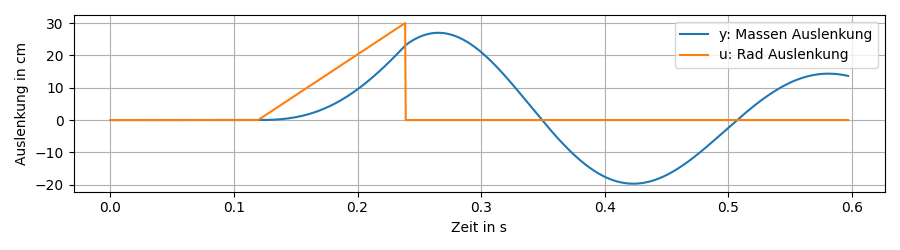

In [18]:
figure(figsize=(9,2.5)); xlabel('Zeit in s'); ylabel('Auslenkung in cm');
plot(t,y*100, label='y: Massen Auslenkung'); plot(t,u*100, label='u: Rad Auslenkung')
legend(); grid(); tight_layout()

# Ziele der heutigen Vorlesung
- Arbeiten mit Messdaten mit Hilfe des `pandas` Pakets
- Frequenzanalyse mittels "Fast Fourier Transformation" (FFT)
- Leckage- und Amplitudenfehler bei der Fourier-Analyse 
- Exkurs: Inituitives Verständnis des Frequenzbereichs
- Optimierungsprobleme mit nicht-konvexen Zielfunktionen
- Einführung in die Modellierung von elektrischen Schaltungen

# 3. Übung FFT Analyse einer Eingangsgröße und Optimierung der Systemantwort

Basis Notebook mit Lücken - ??? - im `share` Ordner oder in Moodle zum Download vorhanden

In [19]:
# Datengenerierung in XLSX
import pandas as pd

dt = 0.02           # Simulationsschritt
v0 = 60/3.6         # 80 km/h
N = int(100/(v0*dt)) +1# Werte pro Meter

np.random.seed(21)

u = 2*sin(linspace(0,2*pi,N, endpoint=False))



U = 2*rfft(u, norm='forward')
U[8:18] += randn(10) * 0.02*e**(1j*np.random.uniform(0, 2 * np.pi, 10)) #* hstack([linspace(0,1,50),linspace(1,0,50)])**2
U[12:112] += randn(100)* 0.006*e**(1j*np.random.uniform(0, 2 * np.pi, 100)) #* hstack([linspace(0,1,400),linspace(1,0,400)])**2
U[:100] += randn(100)* 0.00001*e**(1j*np.random.uniform(0, 2 * np.pi, 100)) #* hstack([linspace(0,1,400),linspace(1,0,400)])**2


f = rfftfreq(len(t), dt)

u = irfft(U/2, norm='forward')

t = arange(len(u))*dt

x = t*v0

data = pd.DataFrame(data={'x-Position':x,'y-Auslenkung':u}, index=t)

data.to_csv('oberflaechen_profil.csv')

### 1. Aufgabe - Einlesen der Daten

Mit der Bibliothek ```pandas``` können aus einer Datenqelle (CSV, EXCEL, usw.) Daten eingelesen werden. Nutze Sie hierfür die Funktion ```read_csv``` um das Oberflächenprofil zu laden und stellen Sie es da.

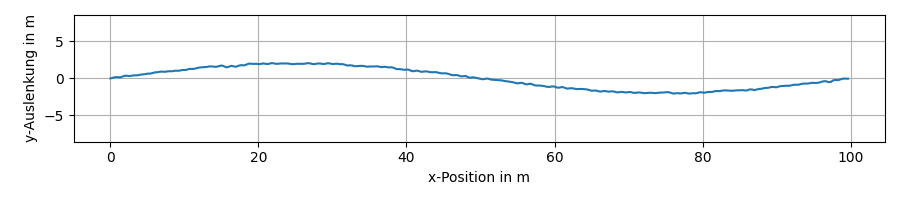

In [20]:
import pandas as pd
df = pd.read_csv('oberflaechen_profil.csv', index_col=0)

t = df.index
y = df['y-Auslenkung']
x = df['x-Position']
figure(figsize=(9,2))
plot(x,y); axis('equal'); grid(); xlabel('x-Position in m'); ylabel('y-Auslenkung in m'); tight_layout()

## 2. Aufgabe - Mit welcher Geschwindigkeit bewegt sich das Fahrzeug?
**Hinweis:** `gradient(...)` Funktion

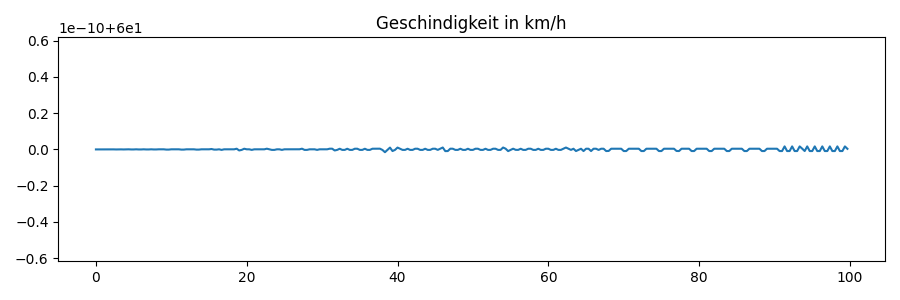

In [21]:
vx = gradient(x) / gradient(t) # dx/dt

figure(figsize=(9,3)); title('Geschindigkeit in km/h')
plot(x,vx*3.6); tight_layout()

## 3. Aufgabe - Welche Beschleunigungen wirken auf das Fahrzeug in vertikaler Richtung?

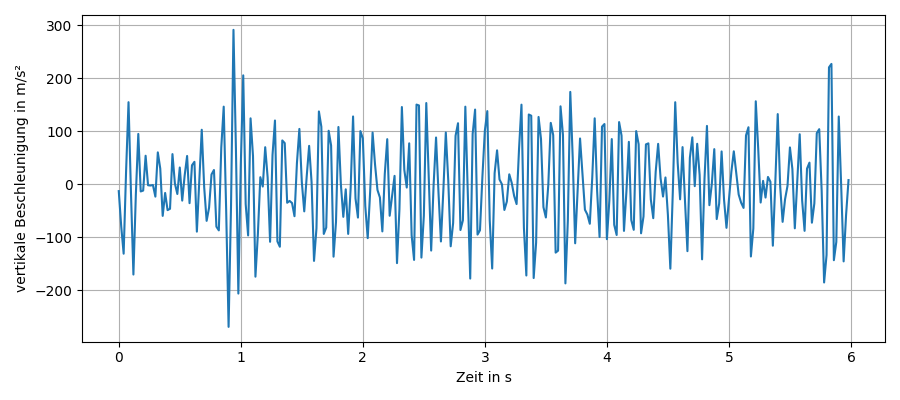

In [22]:
dy  = gradient(y)  / gradient(t)
ddy = gradient(dy) / gradient(t)

figure(figsize=(9,4))
plot(t,ddy); grid(); xlabel('Zeit in s'); ylabel('vertikale Beschleunigung in m/s²'); tight_layout()

## Exkurs: Inituitives Verständnis des Frequenzbereichs

### Zusammenhang zwischen Fourier- und Laplace-Transformation

### Laplace-Transformation

$\mathcal{L}\{f(t)\} = \int_{0}^{\infty} f(t) \mathrm e^{-st} \,\mathrm{d}t, \quad\mathrm{mit}\quad s = j\omega + \sigma$

### Fourier-Transformation
$\mathcal{F}(s) = \int_{0}^{\infty} f(t) \mathrm e^{-j \omega t} \,\mathrm{d}t$

Für stabile periodische Signale sind Fourier- und Laplace-Transformation identisch:<br>$\sigma=0$

## Gleichheit zwischen Fourier-Transformation und Laplace-Transformation

**1.) Bedingung Stabilität:** Begrenzte Eingabe führt zu begrenzter Ausgabe

**2.) Bedingung Periodizität:** Physikalische Systeme haben oft eine Dämpfung, d.h. für $t\to\infty$ klingt eine Anregung auf 0 ab *und* sind kausal, d.h. für $t < 0$ exisitiert noch keine Anregung

Diskrete Fourier-Transformationen lassen sich auf dem Computer durch den Fast-Fourier-Transformation (FFT) Algorithmus sehr schnell berechnen. [Ein Algorithmus für den Weltfrieden](https://www.spektrum.de/kolumne/fast-fourier-transformation-ein-algorithmus-fuer-den-weltfrieden/2078001)

## Veransschaulichung Frequenzbereich (Transformation)



Eine Kurve (eine Funktion) wird in Basisfunktionen ($e^{-st}$ bzw. sin/cos) zerlegt, welche im Frequenzbereich die enthaltenen Frequenzanteile und deren Gewichtung sichtbar macht.

## Diskrete Fourier-Transformation mit Numpy

Die ```numpy``` Funktion ```rfft``` implementiert die schnelle diskreten Fourier-Transformation (FFT). Die zugehörigen Frequenzen können mit ```rfftfreq``` unter Angabe der Schrittweite ```d``` ausgegeben werden.

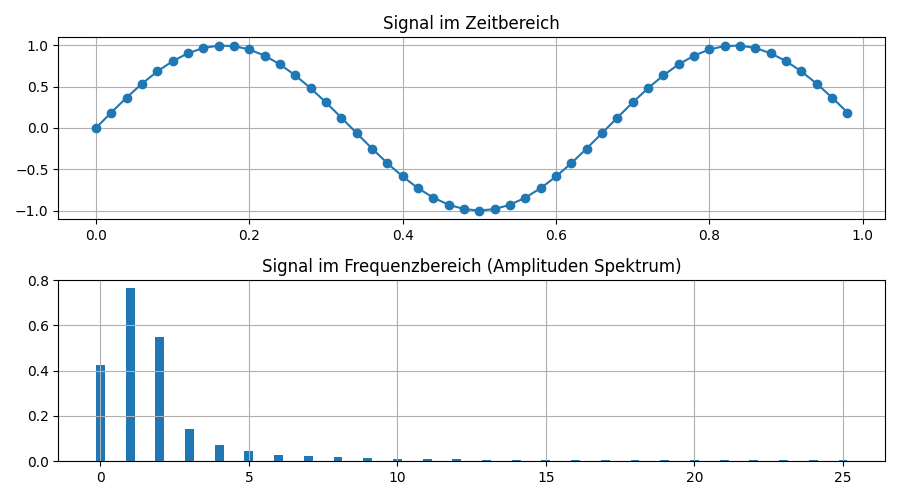

In [23]:
tt = arange(0,1,dt); u = sin(1.5 *2*pi*tt) #+ sin(2 *2*pi*tt)
U = 2*rfft(u, norm='forward')
freq = rfftfreq(len(u), d=dt)

figure(figsize=(9,5))
subplot(211); plot(tt, u, 'o-'); grid(); title('Signal im Zeitbereich')
subplot(212); bar(freq, abs(U), width=0.3); title('Signal im Frequenzbereich (Amplituden Spektrum)')
grid(); tight_layout()

**Hinweis:** Da die Fourier-Transformation von periodischen Signalen ausgeht, führt die Analyse eines endlichen Signalabschnitts zu Diskontinuitäten an den Rändern. Diese bewirken spektrale Leckage, bei der Frequenzanteile erscheinen, die im ursprünglichen Signal nicht vorhanden sind.

## Fensterfunktionen und spektrale Lekage
Fensterfunktionen werden verwendet, um beim Anwenden der Fourier-Transformation auf endliche Signale die spektrale Leckage zu reduzieren und die Genauigkeit der Frequenzanalyse zu verbessern.

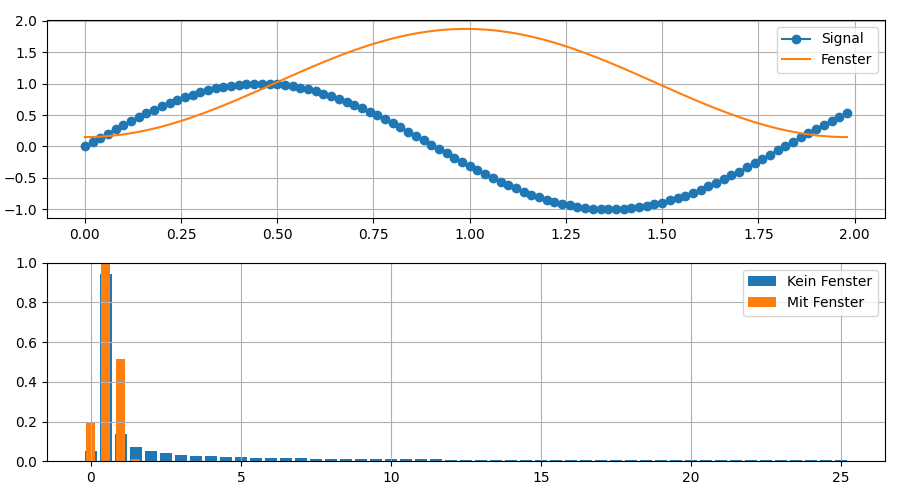

In [24]:
tt = arange(0,2,dt); u = sin(1.1*pi*tt)
win = np.hamming(len(tt))
win *= len(win)/sum(win) # Ampltitudenkorrektur
U     = 2*rfft(u,     norm='forward')
U_win = 2*rfft(u*win, norm='forward')

freq = rfftfreq(len(u), d=dt)

figure(figsize=(9,5))
subplot(211); plot(tt, u, 'o-', label='Signal'); plot(tt, win, label='Fenster'); grid(); legend()
subplot(212); bar(freq, abs(U), width=0.4,label='Kein Fenster'); bar(freq, abs(U_win), width=0.3, label='Mit Fenster'); 
grid(); legend(); ylim(0,1); tight_layout()

## Veransschaulichung Frequenzbereich (Rücktransformation)



## Inverse diskrete Fourier-Transformation mit Numpy
Mit der ```numpy``` Funktion ```irfft``` kann die inversen diskreten Fourier-Transformation berechnet werden.

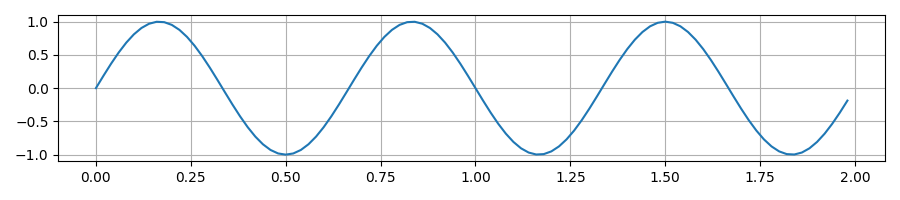

In [25]:
U = zeros(freq.shape, dtype=complex)
U[3] = 0-1j
u = irfft(U/2, norm='forward')
figure(figsize=(9,2)); plot(tt,u); grid(); tight_layout()

**Frage:** Wie kann man einen Sinus erzeugen?

## 4. Aufgabe - Bestimmung der Frequenzanteile in der Radauslenkung. Welche Frequenzen haben die Unebenheiten?

(0.0, 20.0)

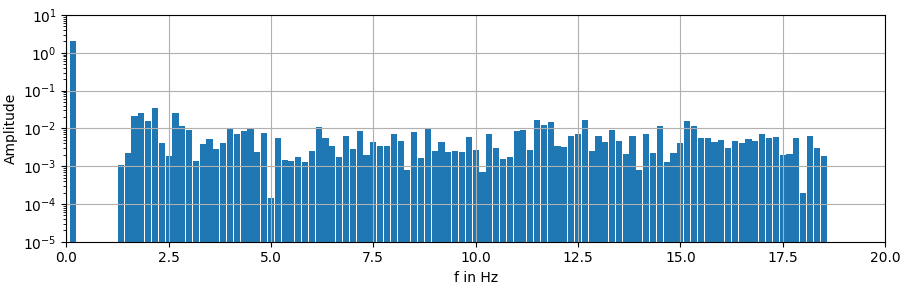

In [26]:
dt  = t[1] -t[0]
f = rfftfreq(len(t), dt)
Y = rfft(y, norm='forward')*2
figure(figsize=(9,3))
bar(f, abs(Y), width=0.15); grid(); xlabel('f in Hz'); ylabel('Amplitude'); tight_layout()
yscale('log'); ylim(1e-5,10); xlim(0,20)

## Veransschaulichung Frequenzbereich (Ableitung)



## Ableitung im Frequenzbereich / Differenzierer

Die Ableitung im Frequenzbereich wird durch die Multiplikation mit $s$ durchgeführt mit $s=jw + \sigma$. Das bedeutet Frequenzanteile werden mit $\omega^2$ verstärkt bei der 2-fachen Ableitung (=Beschleunigung)

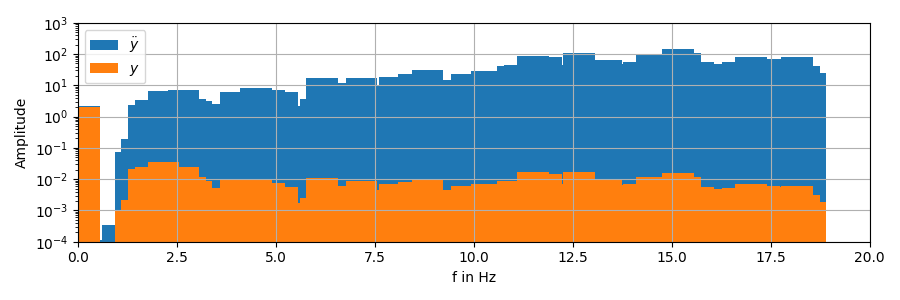

In [27]:
si = 1j*2*pi*f
ddY = Y * si**2 # Spektrum von Y * s²
figure(figsize=(9,3)); bar(f, abs(ddY), label='$\\ddot{y}$'); bar(f, abs(Y), label='$y$');
grid(); xlabel('f in Hz'); ylabel('Amplitude'); yscale('log'); ylim(1e-4,1000); xlim(0,20); legend(); tight_layout()

Es wird ersichtlich, dass die höherfrequenten Anteile im Signal die Beschleunigung definieren (2 Dekanden größer)

## Manipulation im Frequenzbereich (digitale Filter)

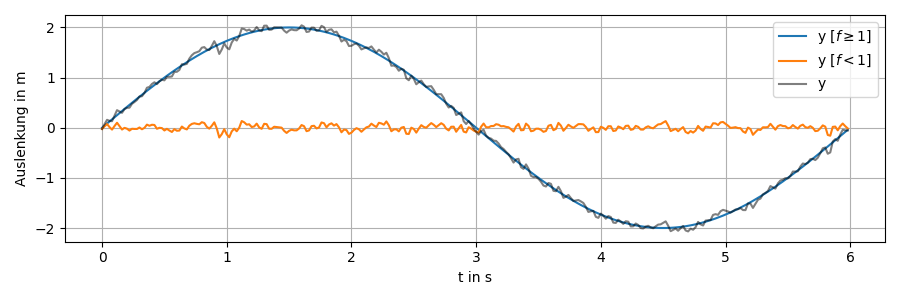

In [28]:
Y2 = copy(Y); Y3 = copy(Y)
Y2[f>1] = 0; Y3[f<=1] = 0
y2 = irfft(Y2/2, norm='forward')
y3 = irfft(Y3/2, norm='forward')

figure(figsize=(9,3))
plot(t, y2, label="y [$f\\geq1$]")
plot(t, y3, label="y [$f<1$]")
plot(t, y, 'k', alpha=0.5, label="y")
legend(); grid(); xlabel('t in s'); ylabel('Auslenkung in m'); tight_layout()

## Veransschaulichung Frequenzbereich (Anwendung der Übertragungsfunktion)



## Amplitudengang der ursprünglichen Federung (aus der letzten Vorlesung)

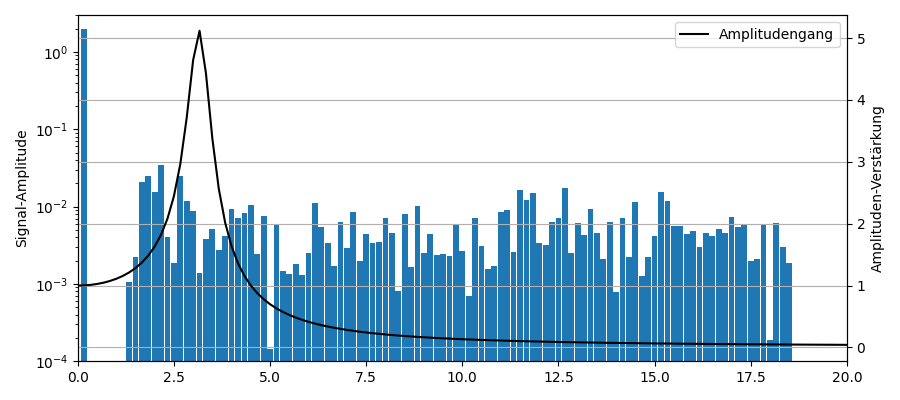

In [29]:
m = 2    # Masse (kg)
k = 800  # Federkonstante (N/m)
d = 8    # Dämpfungskonstante (N.s/m)
G = (s*d+k) / (k + s*d + s**2 *m) # Feder-Masse-Dämpfer-Übertragungsfunktion

Ag,Pg,_ = G.frequency_response(omega=f*2*pi)
t, y1 = ctrl.forced_response(G, t, y)     # Systemantwort für späteren Vergleich

figure(figsize=(9,4))
bar(f,abs(Y), width=0.15); ylabel('Signal-Amplitude'); yscale('log'); ylim(0.0001,3); twinx()
plot(f,Ag, 'k', label='Amplitudengang'); ylabel('Amplituden-Verstärkung'); xlabel('Frequenz');
grid(); xlim(0,20); legend(); tight_layout()

## Auslegung der angepassten Federung für eine niedrigere Grenzfrequenz (aus letzter Vorlesung)

In [30]:
m =  2              # Masse
w0 = 2*pi * 1       # Resonanzfrequenz (ungedämpft)
D =  0.4            # Dämpfungsgrad
k =  w0**2 * m      # Federkonstante
d =  D*2*sqrt(m*k)  # Dämpfungskonstante

G = (s*d+k) / (k + s*d + s**2 *m) # Feder-Masse-Dämpfer-Übertragungsfunktion

print(f"d: {d:4.2f} N/m")
print(f"k: {k:4.2f}")

d: 10.05 N/m
k: 78.96


## 5. Aufgabe - Wie lautet der Amplitudengang bei der angepassten Federung?

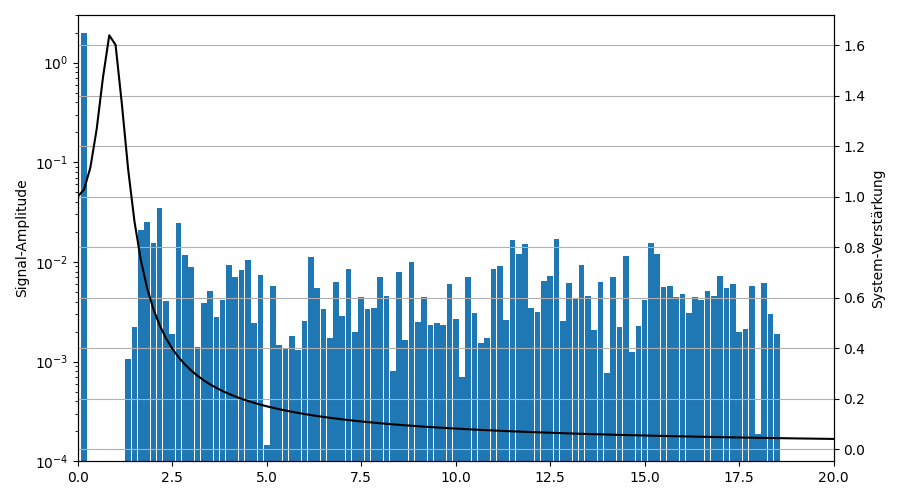

In [31]:
Ag,Pg,_ = G.frequency_response(omega=2*pi*f)

figure(figsize=(9,5))
bar(f,abs(Y), width=0.15); ylabel('Signal-Amplitude'); yscale('log'); ylim(0.0001,3); twinx()
plot(f,Ag, 'k'); ylabel('System-Verstärkung'); xlabel('Frequenz');
grid(); xlim(0,20); tight_layout()

## Vergleich der Federungen 

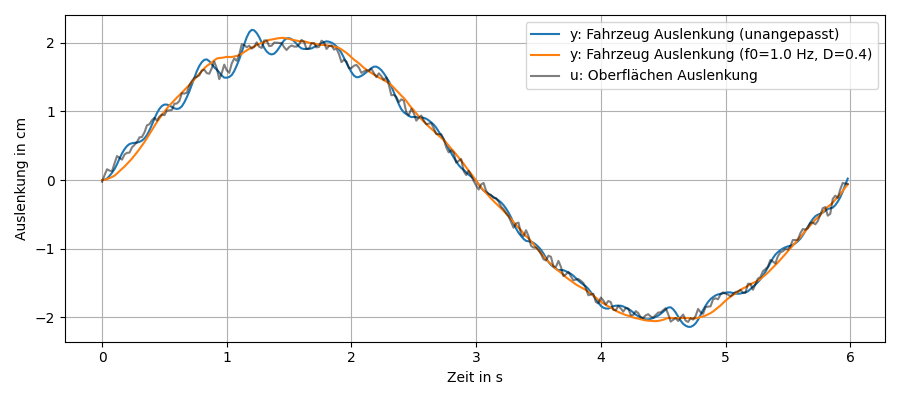

In [32]:
t, y2 = ctrl.forced_response(G, t, y)     # Systemantwort auf die Eingabe (Auslenkung) simulieren

figure(figsize=(9,4)); xlabel('Zeit in s'); ylabel('Auslenkung in cm')
plot(t,y1, label='y: Fahrzeug Auslenkung (unangepasst)')
plot(t,y2, label=f'y: Fahrzeug Auslenkung (f0={w0/2/pi:2.1f} Hz, D={D:2.1f})')
plot(t,y, 'k', alpha=0.5, label='u: Oberflächen Auslenkung')
legend(); grid(); tight_layout()

## Veransschaulichung Frequenzbereich (Anwendung der Übertragungsfunktion)



**Hinweis:** Systeme die durch eine Übertragungsfuntion beschrieben werden können, erzeugen keine neuen Frequenzanteile sondern können Frequenzanteile des Eingangssignals immer nur verstärken oder dämpfen!

## Berechung des Ausgangssignals im Zeitbereich mit Hilfe der IFFT

**Erinnerung:** $y(s) = u(s) G(s)$

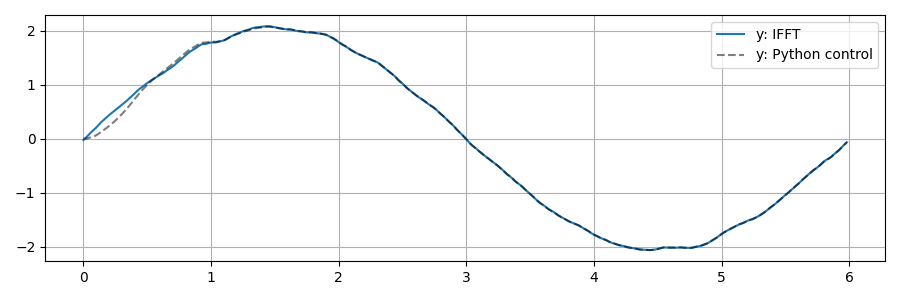

In [33]:
Gd = Ag*e**(1j*Pg)  # frequency_response liefert Amplitude und Phase der komplexen Übertragungsfunktion
Y3 = Y * Gd
y3 = irfft(Y3/2, norm='forward')

figure(figsize=(9,3))
plot(t,y3, label='y: IFFT')
plot(t,y2, 'k--', alpha=0.5, label='y: Python control')
grid(); legend(); tight_layout()

**Frage:** Warum der Unterschied am Anfang?

## 6. Aufgabe - Berechnen Sie die Einfederung und die vertikale Beschleunigung des Fahrzeugs

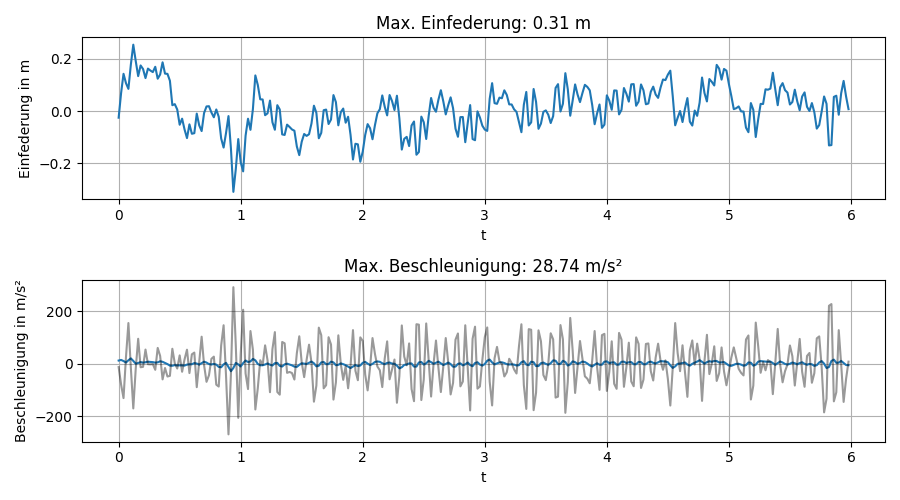

In [34]:
e2 = y-y2
ddy2 = np.gradient(np.gradient(y2))/dt**2

figure(figsize=(9,5))
subplot(211); title(f"Max. Einfederung: {max(abs(e2)):2.2f} m")
plot(t,e2); grid(); xlabel('t'); ylabel('Einfederung in m')
subplot(212); title(f"Max. Beschleunigung: {max(abs(ddy2)):2.2f} m/s²")
plot(t,ddy2); grid(); xlabel('t'); ylabel('Beschleunigung in m/s²')
plot(t,ddy, 'k-', alpha=0.4); xlabel('t'); tight_layout()

## 7. Aufgabe - Gibt es eine Auslegung für die Fahrzeugfederung bei der die  maximale vertikale Beschleunigung weniger als 25 m/s² und die Einfederungung weniger als 27 cm betragen?

## 7. Aufgabe - Lösung mit Optimierer `scipy.optimize`

In [35]:
import scipy as sci

soll_max_a = 10
soll_max_e = 0.6

def opt_federung(params):
    f0, D = params
    w0 = 2*pi*f0
    k =  w0**2 * m      # Federkonstante
    d =  D*2*sqrt(m*k)  # Dämpfungskonstante

    G = (s*d + k)/(m*s**2 + s*d +k) # Feder-Masse-Dämpfer-Übertragungsfunktion

    _, y2 = ctrl.forced_response(G, t, y)     # Systemantwort auf die Eingabe (Auslenkung) simulieren

    e2 = y-y2
    ddy2 = np.gradient(np.gradient(y2))/dt**2
    
    max_e = max(abs(e2))
    max_a = max(abs(ddy2))
    
    # Fehler ist summe der relativen Abweichung => Optimierungskriterium
    err = max([max_e/soll_max_e ,max_a/soll_max_a])
    return err


# Grenzen für f0 und D definieren
bounds = [(0, 2), (0, 1)] 

best_result = None
best_err = np.inf
for _ in range(20):  # 2 zufällige Startpunkte
    start_params = [np.random.uniform(low, high) for low, high in bounds]
    result = sci.optimize.minimize(opt_federung, start_params, method='SLSQP', bounds=bounds)
    if result.fun < best_err:
        best_err = result.fun
        best_result = result
        
# Ausgabe der optimalen Parameter
opt_f0, opt_D = result.x
print(f"Optimierte Werte gefunden: f0 = {opt_f0:0.3f}; D = {opt_D:0.3f}")
print(result)

/opt/conda/lib/python3.12/site-packages/scipy/signal/_lti_conversion.py:74: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  num, den = normalize(num, den)   # Strips zeros, checks arrays


Optimierte Werte gefunden: f0 = 0.000; D = 0.000
 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 3.44659947363358
       x: [ 8.882e-16  6.106e-15]
     nit: 2
     jac: [ 1.058e-05  0.000e+00]
    nfev: 6
    njev: 2


## 7. Aufgabe - Lösung mit Bruteforce

In [36]:
def opt_federung2d(params):
    f0, D = params
    w0 = 2*pi*f0
    k =  w0**2 * m      # Federkonstante
    d =  D*2*sqrt(m*k)  # Dämpfungskonstante

    G = (s*d + k)/(m*s**2 + s*d +k) # Feder-Masse-Dämpfer-Übertragungsfunktion

    _, y2 = ctrl.forced_response(G, t, y)     # Systemantwort auf die Eingabe (Auslenkung) simulieren

    e2 = y-y2
    ddy2 = np.gradient(np.gradient(y2))/dt**2
    
    max_e = max(abs(e2))
    max_a = max(abs(ddy2))
    
    return (max_e, max_a)

# Erstellen eines Meshgrids innerhalb der Grenzen
f0_vals = np.linspace(bounds[0][0], bounds[0][1], 61)  # 31 Punkte für w0
D_vals = np.linspace(bounds[1][0], bounds[1][1], 61)  # 31 Punkte für D
F0, D = np.meshgrid(f0_vals, D_vals)

# Initialisierung der Arrays für max_e und max_a
Max_e = np.zeros(F0.shape)
Max_a = np.zeros(D.shape)

# Durchlaufen des Grids und Berechnung von max_e und max_a
for i in range(F0.shape[0]):
    for j in range(F0.shape[1]):
        max_e, max_a = opt_federung2d([F0[i, j], D[i, j]])
        Max_e[i, j] = max_e
        Max_a[i, j] = max_a

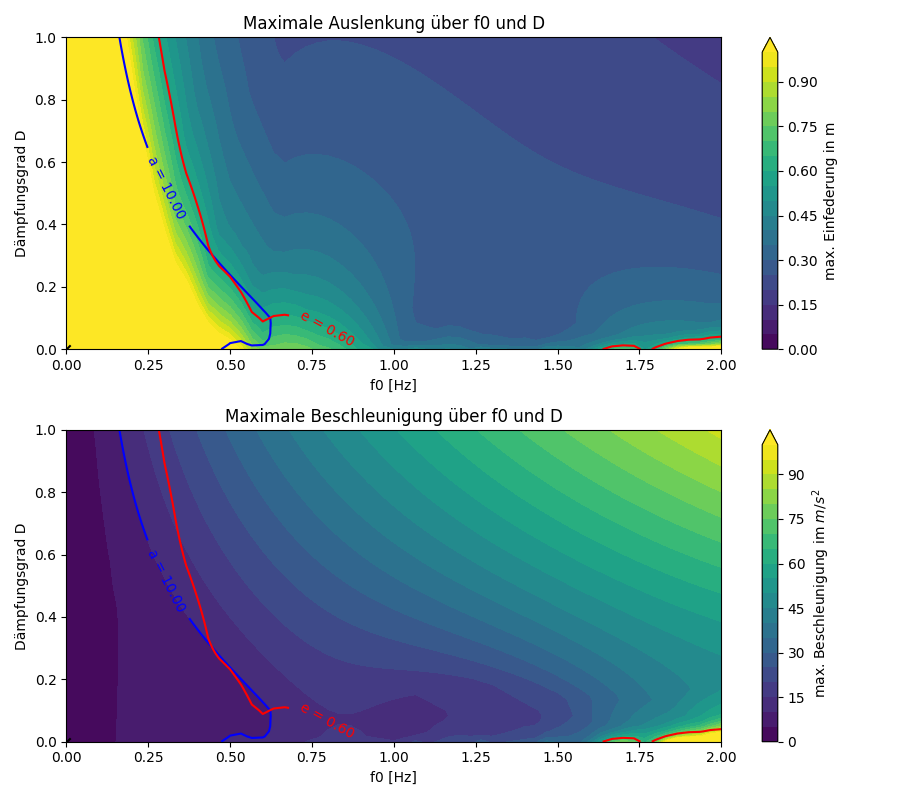

In [37]:
# Plotten von max_e mit der soll_max_e-Linie
figure(figsize=(9, 8))
subplot(211)
contourf(F0, D, Max_e, levels=linspace(0,1,21), extend='max')
colorbar(label='max. Einfederung in m', )
CS_a = plt.contour(F0, D, Max_a, levels=[soll_max_a], colors='blue')
clabel(CS_a, fmt='a = %.2f', inline=True)
CS_e = contour(F0, D, Max_e, levels=[soll_max_e], colors='red')
clabel(CS_e, fmt='e = %.2f', inline=True)
scatter( opt_f0, opt_D, c='k', marker='x')
xlabel('f0 [Hz]')
ylabel('Dämpfungsgrad D')
title('Maximale Auslenkung über f0 und D')


# Plotten von max_a mit der soll_max_a-Linie
subplot(212)
plt.contourf(F0, D, Max_a, levels=linspace(0,100,21), extend='max')  
colorbar(label='max. Beschleunigung im $m/s^2$')
CS_a = plt.contour(F0, D, Max_a, levels=[soll_max_a], colors='blue')
clabel(CS_a, fmt='a = %.2f', inline=True)
CS_e = contour(F0, D, Max_e, levels=[soll_max_e], colors='red')
clabel(CS_e, fmt='e = %.2f', inline=True)
scatter( opt_f0, opt_D, c='k', marker='x')
xlabel('f0 [Hz]')
ylabel('Dämpfungsgrad D')
title('Maximale Beschleunigung über f0 und D')
tight_layout()

# Simulation eines Elektromotors (Ankerstrom)



# Simulation von elektrischen Schaltungen

## Simulation von einfachen elektrischen Bauteilen

Welche physikalischen Größen sind bei elektrischen Schaltung häufig Eingang bzw. Ausgang?

**Spannung U** und **Stromstärke I**

Wie lautet die Übertragungsfunktion für einen Widerstand R mit der Spannung als Eingang und dem Strom als Ausgang?


$G_R = i/u = 1/R$

## Übertragungsfunktion der Spule

Wie lautet die Beziehung zwischen Strom und Spannung bei der Spule?

$u(t) = L \cdot \frac{d i(t)}{dt}$

Die Übertragungsfunktion für die Spule mit der Spannung als Eingang und dem Strom als Ausgang?

$G_L = \frac{i}{u} = \frac{s}{L}$

## Übertragungsfunktion des Kondensators

Wie lautet die Beziehung zwischen Strom und Spannung beim Kondensator?

$u(t) = C \int i(t) dt$

Die Übertragungsfunktion für den Kondesator mit der Spannung als Eingang und dem Strom als Ausgang?

$G_L = \frac{i}{u} = \frac{1}{sC}$

## Simulation eines RC-Tiefpasses

Wie lautet die Übertragungsfunktion Ua / Ue?

**Hinweis:** Knoten und Maschenregel

## Übertragungsfunktion des RC-Tiefpasses

In [38]:
import sympy as sy

Ue, Ua, I, R, C, s = sy.symbols("U_e U_a I R C s")

eq1 = Ue - I*(R+1/(s*C))
eq2 = Ua - I*(1/(s*C))

display(eq1)
display(eq2)

-I*(R + 1/(C*s)) + U_e

U_a - I/(C*s)

In [39]:
sy.solve([eq1,eq2], [Ua,I])[Ua]/Ue

1/(C*R*s + 1)

## Modellierung des RC-Tiefpasses

In [40]:
s = ctrl.tf("s")

R = 10e3  # 10 kOhm
C = 1e-6  # 1 uF

G = 1/(R*C*s+1)

In [41]:
ctrl.damp(G)

    Eigenvalue (pole)       Damping     Frequency
                 -100             1           100


(array([100.]), array([1.]), array([-100.+0.j]))

Grenzfrequenz (3dB Dämpfung)

In [42]:
fg = 1/(R*C*2*pi)

display(fg*2*pi)

100.0

## Bodeplot des RC-Tiefpasses

/tmp/ipykernel_50/3326443535.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  figure(figsize=(9,5))


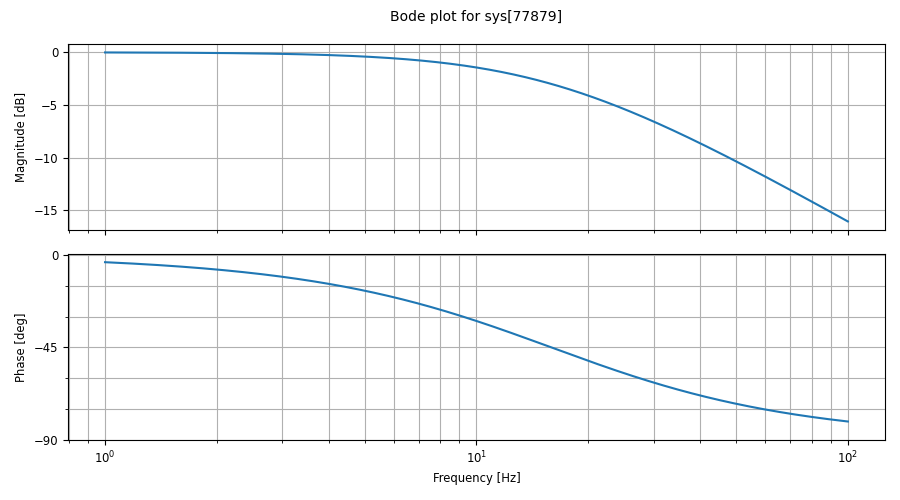

In [43]:
figure(figsize=(9,5))
_ = ctrl.bode(G, Hz=True, dB=True)

## Simulation des Tiefpasses

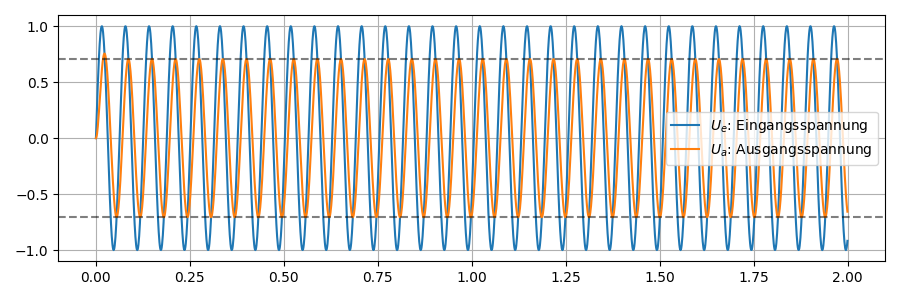

In [44]:
dt = 1e-3
t = arange(0,2,dt)
u = sin(2*pi*t*fg)
t, y = ctrl.forced_response(G, t, u)     # Systemantwort auf die Eingabe

figure(figsize=(9,3))
plot(t,u, label='$U_e$: Eingangsspannung')
plot(t,y,  label='$U_a$: Ausgangsspannung')
grid(); legend(); tight_layout()
axhline(1/sqrt(2), ls='--', c='k', alpha=0.5); axhline(-1/sqrt(2), ls='--', c='k', alpha=0.5)

In [45]:
1/sqrt(2)

np.float64(0.7071067811865475)

## Simulation eines Schwingkreises

## Übertragungsfunktion des gedämpften Schwingkreises

In [46]:
import sympy as sy

Ue, Ua, I, R, C, L, s = sy.symbols("U_e U_a I R C L s")

eq1 = I* R + I* s*L + I* 1/(s*C) - Ue
eq2 = Ua - I*1/(s*C)

display(eq1)
display(eq2)

I*L*s + I*R - U_e + I/(C*s)

U_a - I/(C*s)

In [47]:
sy.solve([eq1,eq2], [Ua,I])[Ua]/Ue

1/(C*L*s**2 + C*R*s + 1)

## Modellierung des gedämpften Schwingkreises

In [48]:
s = ctrl.tf("s")

R = 100   # 100 Ohm
L = 100e-3 # 100 mH
C = 1e-6   # 1 uF


G = 1/(s**2 *C*L+s*C*R + 1)

In [49]:
ctrl.damp(G)

    Eigenvalue (pole)       Damping     Frequency
      -500     +3122j        0.1581          3162
      -500     -3122j        0.1581          3162


(array([3162.27766017, 3162.27766017]),
 array([0.15811388, 0.15811388]),
 array([-500.+3122.4989992j, -500.-3122.4989992j]))

In [50]:
fr = 1/(2*pi*sqrt(L*C))
display(fr)

np.float64(503.2921210448704)

## Bodeplot des gedämpften Schwingkreises

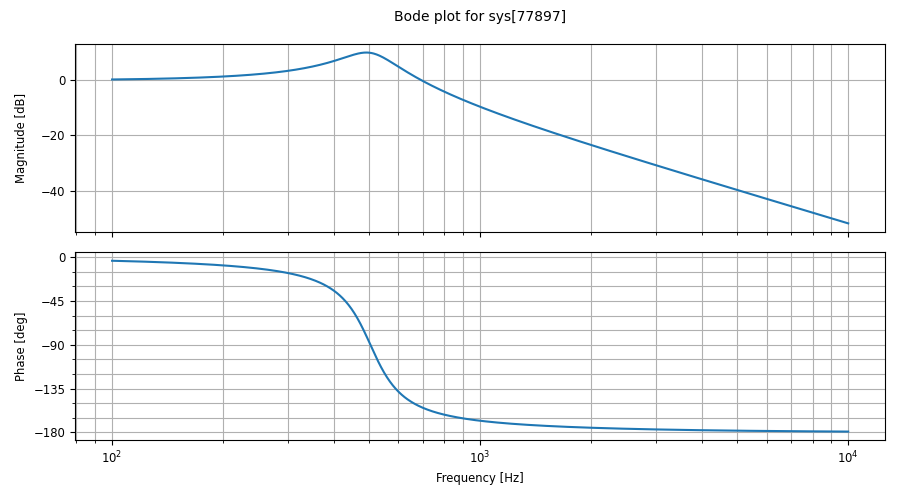

In [51]:
figure(figsize=(9,5))
_ = ctrl.bode(G, Hz=True, dB=True)

## Simulation des Schwingkreises

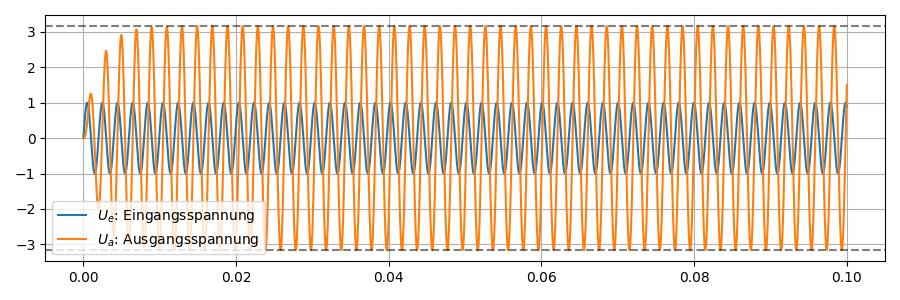

In [52]:
dt = 1e-6
t = arange(0,0.1,dt)
u = sin(2*pi*t*fr)
t, y = ctrl.forced_response(G, t, u)     # Systemantwort auf die Eingabe

figure(figsize=(9,3))
plot(t,u, label='$U_e$: Eingangsspannung')
plot(t,y, label='$U_a$: Ausgangsspannung')
grid(); legend(); tight_layout()
axhline(3.16, ls='--', c='k', alpha=0.5); axhline(-3.16, ls='--', c='k', alpha=0.5)

**Frage:** Woher kommt der Faktor 3.16?

**Antwort:** $|G(j\omega_0)| = \frac{1}{\omega_0 R C} = \frac{\sqrt{L/C}}{R}$ (aus Formelsammlung)

In [53]:
sqrt(L/C)/100

np.float64(3.1622776601683795)

# Wie lautet die Übertragungsfunktion für den 1. Block im Modell eines Elektromotors?



## Übertragungsfunktion des Ankerstroms

In [54]:
import sympy as sy

Ue, Ua, U_i, I, R, C, L, s = sy.symbols("U_e U_a U_i I R C L s")

eq = I* R + I*L*s - Ue

display(eq)

I*L*s + I*R - U_e

In [55]:
sy.solve([eq], [I])[I]/Ue

1/(L*s + R)

## Modellierung des Ankerstroms

In [56]:
s = ctrl.tf("s")

R = 3.1    # Elektrischer Widerstand der Ankerspule in Ohm
L = 2.9e-3 # Induktivität der Ankerspule in H

G = 1/(L*s + R)

In [57]:
fg, _,_ = ctrl.damp(G)

    Eigenvalue (pole)       Damping     Frequency
                -1069             1          1069


In [58]:
print(f'Grenzfrequenz: {fg[0]/2/pi:3.2f}')

Grenzfrequenz: 170.13


## Bodeplot des Ankerstrom-Tiefpasses

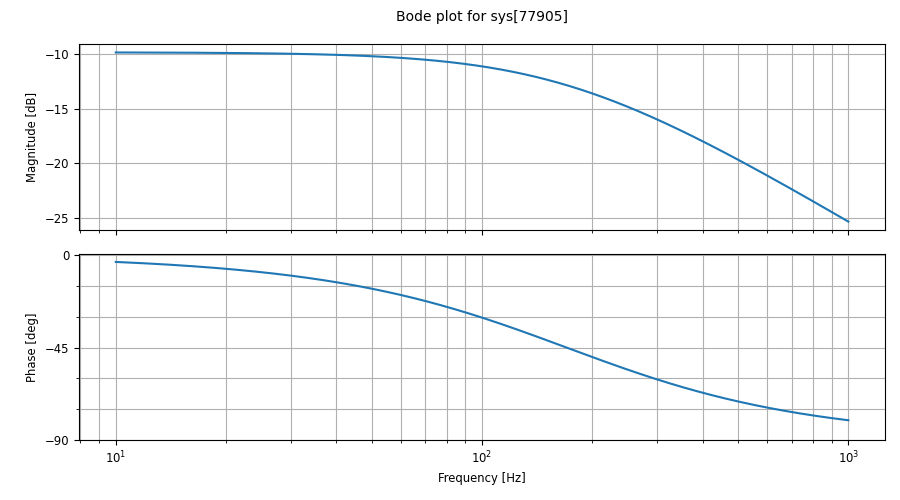

In [59]:
figure(figsize=(9,5))
_ = ctrl.bode(G, Hz=True, dB=True)

## Simulation des Ansteigs des Ankerstroms

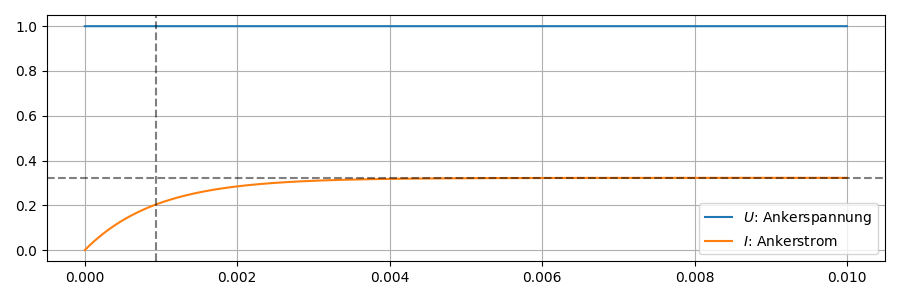

In [60]:
dt = 1e-6
t = arange(0,0.01,dt)
u = ones(t.shape)
t, y = ctrl.forced_response(G, t, u)     # Systemantwort auf die Eingabe

figure(figsize=(9,3))
plot(t,u, label='$U$: Ankerspannung')
plot(t,y, label='$I$: Ankerstrom')
grid(); legend(); tight_layout()
axhline(1/R, ls='--', c='k', alpha=0.5); axvline(1/fg, ls='--', c='k', alpha=0.5);

In [61]:
!jupyter nbconvert "Vorlesung 3 - Frequenz Analyse und Simulation elektr. Systeme.ipynb" --to slides
# Kann mit Firefox als PDF gedruckt werden

[NbConvertApp] Converting notebook Vorlesung 3 - Frequenz Analyse und Simulation elektr. Systeme.ipynb to slides
[NbConvertApp] WARNING | Alternative text is missing on 33 image(s).
[NbConvertApp] Writing 2111827 bytes to Vorlesung 3 - Frequenz Analyse und Simulation elektr. Systeme.slides.html
